In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt


In [3]:
# Make outputs reproducible 
np.random.seed(42)

#Nicer float display in pandas
pd.set_option("display.float_format", lambda x: f"{x: .3f}")

## Part 1 - Data Cleaning & Preprocessing
Real datasets are almost never clean. Before training any ML model we need to handle things like:

- Missing values ('NaN')
- Duplicated rows
- Inconsistent text (capitalization, whitespace)
- Wrong data types
- Outliers
- Features on very different scales

We will build three small synthetic datasets, each designed to illustrate a specific problem.

In [4]:
#Dataset A: students with missing values
dataset_a= pd.DataFrame({
    "student_id": [1, 2, 3, 4, 5, 6, 7, 8],
    "age": [20, 21, np.nan, 22, 23, 20, np.nan, 24],
    "study_hours": [10, 12, 8, np.nan, 15, 9, 11, 14],
    "score": [78, 82, 65, 70, np.nan, 72, 80, 88]
})
dataset_a

,student_id,age,study_hours,score
0,1,20.000,10.000,78.000
1,2,21.000,12.000,82.000
2,3,NaN,8.000,65.000
3,4,22.000,NaN,70.000
4,5,23.000,15.000,NaN
5,6,20.000,9.000,72.000
6,7,NaN,11.000,80.000
7,8,24.000,14.000,88.000


In [5]:
# Step 1: detect missing values per calumn
print("Missing values per column:")
print(dataset_a.isna().sum())

Missing values per column:
student_id     0
age            2
study_hours    1
score          1
dtype: int64


In [6]:
#Step 2: impute (fill) missing values
#Strategy: fill numeric columns with the column mean
#This is a simple, very common baseline strategy

dataset_a_clean = dataset_a.copy()

for col in ["age", "study_hours", "score"]:
    mean_value = dataset_a_clean[col].mean()
    dataset_a_clean[col] = dataset_a_clean[col].fillna(mean_value)

dataset_a_clean

,student_id,age,study_hours,score
0,1,20.000,10.000,78.000
1,2,21.000,12.000,82.000
2,3,21.667,8.000,65.000
3,4,22.000,11.286,70.000
4,5,23.000,15.000,76.429
5,6,20.000,9.000,72.000
6,7,21.667,11.000,80.000
7,8,24.000,14.000,88.000


**Note:** The mean is only one of several imputation strategies. Other
common options are the **median** (more robus to outliers), the **mode**
(userful for categorical columns), or more advanced techniques like KNN 
imputation. The right choice depends on the data.

In [7]:
#Dataset B: dirty car sales data
dataset_b = pd.DataFrame({
    "brand": ["Toyota", "toyota", "HONDA", "Ford", "ford", "Toyota", "Honda ", "TOYOTA"],
    "model": ["Corolla", "Corolla", "Civic", "Focus", "Focus", "Corolla", "Civic", "Corolla"],
    "price": ["15000", "15000", "18000", "12000", "12000", "15000", "18500", "15000"],
    "year": [2018, 2018, 2019, 2017, 2017, 2018, 2020, 2018]
})

dataset_b

,brand,model,price,year
0,Toyota,Corolla,15000,2018
1,toyota,Corolla,15000,2018
2,HONDA,Civic,18000,2019
3,Ford,Focus,12000,2017
4,ford,Focus,12000,2017
5,Toyota,Corolla,15000,2018
6,Honda,Civic,18500,2020
7,TOYOTA,Corolla,15000,2018


In [8]:
#Step 1: check data types.
#Notice that "price" is an 'object' (string), not a numbres.
dataset_b.dtypes

brand      str
model      str
price      str
year     int64
dtype: object

In [9]:
#Step 2: normalize text in the 'brand' column
#- strip() removes leading/trailing whitespace
#- str.title() converts to Title case ("toyota" -> "Toyota")
dataset_b_clean = dataset_b.copy()
dataset_b_clean["brand"] = dataset_b_clean["brand"].str.strip().str.title()

In [10]:
#Step 3: convert 'price' from string to numeric
dataset_b_clean["price"] = pd.to_numeric(dataset_b_clean["price"])

In [11]:
#Step 4: remove duplicated rows
print(f"Rows before removing duplicates: {len(dataset_b_clean)}")
dataset_b_clean = dataset_b_clean.drop_duplicates().reset_index(drop=True)
print(f"Rows after removing duplicates: {len(dataset_b_clean)}")

dataset_b_clean

Rows before removing duplicates: 8
Rows after removing duplicates: 4


,brand,model,price,year
0,Toyota,Corolla,15000,2018
1,Honda,Civic,18000,2019
2,Ford,Focus,12000,2017
3,Honda,Civic,18500,2020


In [12]:
#Verify that data types are now correct
dataset_b_clean.dtypes

brand      str
model      str
price    int64
year     int64
dtype: object

### Dataset C - Outliers and Feature scaling

Ouliers are values that are very different from the rest of the data.
They can be legitimate, but they can also be erros (e.g.,a typo).

Feature scaling is importan when features live on very different 
numerical ranges - for example, a car's weight (thousands of pounds) vs.
its number of cylinders (4-8). Without scaling, features with larger
ranges can dominate the learning process.

In [13]:
#Dataset C: car specs with one clear outlier in 'weight'
dataset_c = pd.DataFrame({
    "weight": [3.50, 3.69, 3.44, 3.43, 4.34, 4.42, 2.37, 25.00], # last row is a typo
    "horsepower": [130, 165, 150, 140, 198, 220, 95,  180],
    "cylinders": [4, 6, 4, 4, 8, 8, 4, 6],
    "mpg": [18, 15, 18, 16, 15 ,14, 24, 17]
})

dataset_c

,weight,horsepower,cylinders,mpg
0,3.500,130,4,18
1,3.690,165,6,15
2,3.440,150,4,18
3,3.430,140,4,16
4,4.340,198,8,15
5,4.420,220,8,14
6,2.370,95,4,24
7,25.000,180,6,17


In [14]:
#Step 1: detect outliers in 'weight' using the IQR (InterQuearile Range) rule.
# A value is considered an outlier if it falls outside [01 - 1.5*IQR, Q3 + 1.5*IQR].
q1 = dataset_c["weight"].quantile(0.25)
q3 = dataset_c["weight"].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

print(f"Q1 = {q1:.2f}, Q3 = {q3:.2f}, IQR = {iqr:.2f}")
print(f"Valid range for 'weight': [{lower_bound:.2f}, {upper_bound:.2f}]")

outliers_mask = (dataset_c["weight"] < lower_bound) | (dataset_c["weight"] > upper_bound)

print("\nOutlier rows:")
dataset_c[outliers_mask]

Q1 = 3.44, Q3 = 4.36, IQR = 0.92
Valid range for 'weight': [2.05, 5.74]

Outlier rows:


,weight,horsepower,cylinders,mpg
7,25.000,180,6,17


In [15]:
#Step 2: remove outliers
dataset_c_clean = dataset_c[~outliers_mask].reset_index(drop=True)
dataset_c_clean

,weight,horsepower,cylinders,mpg
0,3.500,130,4,18
1,3.690,165,6,15
2,3.440,150,4,18
3,3.430,140,4,16
4,4.340,198,8,15
5,4.420,220,8,14
6,2.370,95,4,24


In [16]:
#Step 3 feature scaling using Min-Max normalization.
#Formula: x_scaled = (x - x_min) / (x_max - x_min)
#After scaling, every feature lives in the range [0, 1]

features_to_scale = ["weight", "horsepower", "cylinders"]
dataset_c_scaled = dataset_c_clean.copy()

for col in features_to_scale:
    col_min = dataset_c_scaled[col].min()
    col_max = dataset_c_scaled[col].max()
    dataset_c_scaled[col] = (dataset_c_scaled[col] - col_min) / (col_max - col_min)

dataset_c_scaled

,weight,horsepower,cylinders,mpg
0,0.551,0.280,0.000,18
1,0.644,0.560,0.500,15
2,0.522,0.440,0.000,18
3,0.517,0.360,0.000,16
4,0.961,0.824,1.000,15
5,1.000,1.000,1.000,14
6,0.000,0.000,0.000,24


Linear regression

In [17]:
cars = pd.DataFrame({
    "weight": [3.5, 3.69, 3.44, 3.43, 4.34, 4.42, 2.34],
    "mpg": [18, 15, 18, 16, 15, 14, 24],
})

cars

,weight,mpg
0,3.500,18
1,3.690,15
2,3.440,18
3,3.430,16
4,4.340,15
5,4.420,14
6,2.340,24


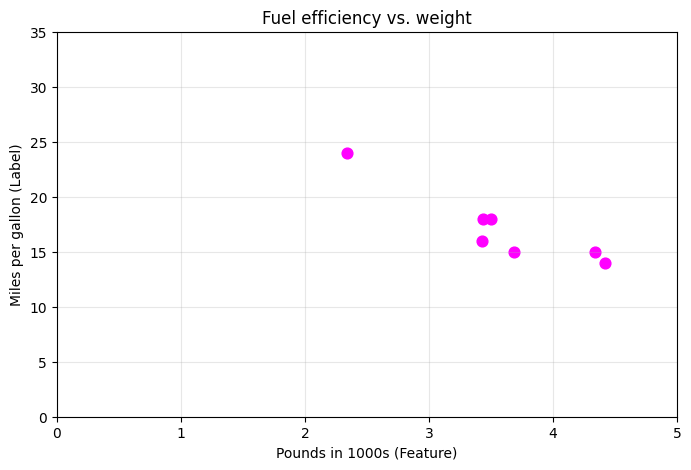

In [18]:
#Visualize the data (same scatter plot as in the slides)
plt.figure(figsize=(8, 5))
plt.scatter(cars["weight"], cars["mpg"], color="magenta", s=60)
plt.xlabel("Pounds in 1000s (Feature)")
plt.ylabel("Miles per gallon (Label)")
plt.title("Fuel efficiency vs. weight")
plt.xlim(0, 5)
plt.ylim(0, 35)
plt.grid(True, alpha=0.3)
plt.show()

In [19]:
x1, y1 = 4.0, 15.6
x2, y2 = 0.0, 34.0
#Slope (weight) usig the slope formula
w1 = (y2 - y1) / (x2 - x1)
#Bias is the y-intercept (y-value when x = 0)
b = y2

print(f"Weight w1 = {w1:.2f}")
print(f"Bias (b) = {b: .2f}")
print(f"\nModel: y' = {b} + ({w1})*x1")

Weight w1 = -4.60
Bias (b) =  34.00

Model: y' = 34.0 + (-4.6)*x1


In [20]:
#model 
def predict(x, bias, weight):
    return bias + weight * x

In [22]:
#predictions
cars["predicted_mpg"] = predict(cars["weight"], b, w1)
cars

,weight,mpg,predicted_mpg
0,3.500,18,17.900
1,3.690,15,17.026
2,3.440,18,18.176
3,3.430,16,18.222
4,4.340,15,14.036
5,4.420,14,13.668
6,2.340,24,23.236
